# Hate Speech and Offensive Language Detection on Social Media Using NLP

**Course:** IE7500 — Applied Natural Language Processing in Engineering
**Team:** Ana Luiza Young Pessoa, Mus Ab Wilmaz, Liang Wang

This notebook implements the pipeline described in the Milestone 1 project proposal:
comparing a **TF-IDF + Logistic Regression** baseline against a **fine-tuned DistilBERT**
model for 3-class classification of tweets into `hate speech`, `offensive language`, and
`neither`, using the Davidson et al. (2017) dataset.

**Sections:**
1. Setup and Imports
2. Data Loading
3. Exploratory Data Analysis (EDA)
4. Preprocessing
5. Train / Validation / Test Split
6. Baseline Model: TF-IDF + Logistic Regression
7. Transformer Model: Fine-tuned DistilBERT
8. Evaluation and Comparison
9. Bias and Error Analysis
10. Conclusions and Next Steps


## 1. Setup and Imports

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import re
import string
import random

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn (baseline model)
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
)

# Imbalanced-learn (SMOTE for class imbalance handling)
# pip install imbalanced-learn
from imblearn.over_sampling import SMOTE

# Transformers (DistilBERT fine-tuning)
# pip install transformers datasets torch accelerate
import torch
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

pd.set_option("display.max_colwidth", 200)
sns.set_theme(style="whitegrid")


Matplotlib is building the font cache; this may take a moment.


## 2. Data Loading

Dataset: [Davidson et al. (2017) — Hate Speech and Offensive Language](https://github.com/t-davidson/hate-speech-and-offensive-language),
mirrored on Hugging Face Datasets as `tdavidson/hate_speech_offensive`.

Label mapping:
- `0` → hate speech
- `1` → offensive language
- `2` → neither


In [2]:
# Load dataset directly from Hugging Face (parquet)
df = pd.read_parquet("hf://datasets/tdavidson/hate_speech_offensive/data/train-00000-of-00001.parquet")

print(df.shape)
df.head()


(24783, 6)


,count,hate_speech_count,offensive_language_count,neither_count,class,tweet
0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't complain about cleaning up your house. &amp; as a man you should always take the trash out...
1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn bad for cuffin dat hoe in the 1st place!!
2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby4life: You ever fuck a bitch and she start to cry? You be confused as shit
3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she look like a tranny
4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you hear about me might be true or it might be faker than the bitch who told it to ya &#57361;


In [3]:
# Map numeric class to readable label
label_map = {0: "hate_speech", 1: "offensive_language", 2: "neither"}
df["label_name"] = df["class"].map(label_map)

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 24783 entries, 0 to 24782
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   count                     24783 non-null  int64
 1   hate_speech_count         24783 non-null  int64
 2   offensive_language_count  24783 non-null  int64
 3   neither_count             24783 non-null  int64
 4   class                     24783 non-null  int64
 5   tweet                     24783 non-null  str  
 6   label_name                24783 non-null  str  
dtypes: int64(5), str(2)
memory usage: 3.7 MB


## 3. Exploratory Data Analysis (EDA)

- Class distribution
- Tweet length statistics
- Duplicate / missing value checks
- Vocabulary overlap across classes (TODO)


label_name
offensive_language    19190
neither                4163
hate_speech            1430
Name: count, dtype: int64
label_name
offensive_language    77.43
neither               16.80
hate_speech            5.77
Name: proportion, dtype: float64


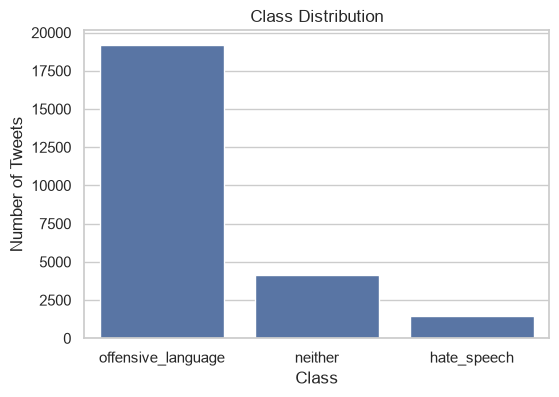

In [4]:
# Class distribution
class_counts = df["label_name"].value_counts()
class_pct = df["label_name"].value_counts(normalize=True) * 100

print(class_counts)
print(class_pct.round(2))

plt.figure(figsize=(6, 4))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title("Class Distribution")
plt.ylabel("Number of Tweets")
plt.xlabel("Class")
plt.show()


In [5]:
# Missing values and duplicates
print("Missing values per column:")
print(df.isnull().sum())

print("\nDuplicate tweets:", df.duplicated(subset=["tweet"]).sum())


Missing values per column:
count                       0
hate_speech_count           0
offensive_language_count    0
neither_count               0
class                       0
tweet                       0
label_name                  0
dtype: int64

Duplicate tweets: 0


                      count       mean       std  min  25%   50%   75%   max
label_name                                                                  
hate_speech          1430.0  13.906993  7.037868  1.0  8.0  13.5  20.0  32.0
neither              4163.0  14.919289  6.801590  1.0  9.0  15.0  20.0  52.0
offensive_language  19190.0  13.958624  6.802658  1.0  8.0  13.0  19.0  36.0


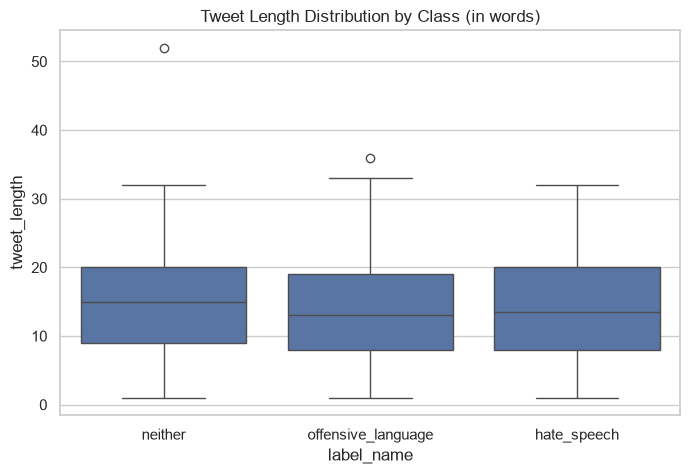

In [6]:
# Tweet length statistics (in words)
df["tweet_length"] = df["tweet"].apply(lambda x: len(str(x).split()))

print(df.groupby("label_name")["tweet_length"].describe())

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="label_name", y="tweet_length")
plt.title("Tweet Length Distribution by Class (in words)")
plt.show()


**TODO (team):**
- Vocabulary overlap analysis across classes (e.g., top n-grams per class, Jaccard similarity)
- Word clouds per class (optional, for the report)


## 4. Preprocessing

- Lowercasing
- URL and @mention removal
- Punctuation / special character handling
- Tokenization (for baseline: handled by TfidfVectorizer; for DistilBERT: handled by tokenizer)


In [7]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)          # remove URLs
    text = re.sub(r"@\w+", " ", text)                        # remove mentions
    text = re.sub(r"#", "", text)                             # keep hashtag word, drop symbol
    text = re.sub(r"[^a-z\s']", " ", text)                    # remove non-alphabetic chars
    text = re.sub(r"\s+", " ", text).strip()                  # collapse whitespace
    return text

df["clean_tweet"] = df["tweet"].apply(clean_text)
df[["tweet", "clean_tweet"]].head()


,tweet,clean_tweet
0,!!! RT @mayasolovely: As a woman you shouldn't complain about cleaning up your house. &amp; as a man you should always take the trash out...,rt as a woman you shouldn't complain about cleaning up your house amp as a man you should always take the trash out
1,!!!!! RT @mleew17: boy dats cold...tyga dwn bad for cuffin dat hoe in the 1st place!!,rt boy dats cold tyga dwn bad for cuffin dat hoe in the st place
2,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby4life: You ever fuck a bitch and she start to cry? You be confused as shit,rt dawg rt you ever fuck a bitch and she start to cry you be confused as shit
3,!!!!!!!!! RT @C_G_Anderson: @viva_based she look like a tranny,rt she look like a tranny
4,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you hear about me might be true or it might be faker than the bitch who told it to ya &#57361;,rt the shit you hear about me might be true or it might be faker than the bitch who told it to ya


## 5. Train / Validation / Test Split

Stratified split: 70% train, 15% validation, 15% test.


In [8]:
X = df["clean_tweet"]
y = df["class"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED
)

print("Train:", X_train.shape, " Val:", X_val.shape, " Test:", X_test.shape)


Train: (17348,)  Val: (3717,)  Test: (3718,)


## 6. Baseline Model: TF-IDF + Logistic Regression

Class imbalance handled via `class_weight="balanced"` (SMOTE is provided as an
alternative below — TODO next milestone: decide which strategy to keep).


In [9]:
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=3,
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

print(X_train_tfidf.shape)


(17348, 10000)


In [10]:
# First solution on imbalanced: class_weight balancing
baseline_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=SEED,
)
baseline_model.fit(X_train_tfidf, y_train)


,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

In [ ]:
# Option B (alternative, TODO: compare against Option A): SMOTE oversampling
# smote = SMOTE(random_state=SEED)
# X_train_res, y_train_res = smote.fit_resample(X_train_tfidf, y_train)
# baseline_model_smote = LogisticRegression(max_iter=1000, random_state=SEED)
# baseline_model_smote.fit(X_train_res, y_train_res)


In [11]:
y_val_pred_baseline = baseline_model.predict(X_val_tfidf)

print(classification_report(y_val, y_val_pred_baseline, target_names=label_map.values()))
print("Macro F1 (validation):", f1_score(y_val, y_val_pred_baseline, average="macro"))


                    precision    recall  f1-score   support

       hate_speech       0.36      0.63      0.46       215
offensive_language       0.97      0.86      0.91      2878
           neither       0.75      0.93      0.83       624

          accuracy                           0.86      3717
         macro avg       0.69      0.81      0.73      3717
      weighted avg       0.90      0.86      0.87      3717

Macro F1 (validation): 0.7336635233118253


Based on the outputs we can notice that precision is bad on hate_speech dataset; we need to refine the models on a later tassk

## 7. Transformer Model: Fine-tuned DistilBERT

**TODO (team, before running — this is compute/GPU intensive):**
- Confirm environment has GPU access
- Confirm batch size / epochs given available compute
- Decide max sequence length


In [13]:
#### test GPU

import torch
print(torch.cuda.is_available())

False


In [14]:
###### to run in case GPU not available
# --- CPU-friendly configuration 
#  ---
N_SAMPLE_TRAIN = 3000   # subset of X_train/y_train to use (set to None to use all of X_train)
N_SAMPLE_EVAL = 600     # subset of X_val/y_val to use for evaluation during training
MAX_LENGTH = 64
BATCH_SIZE = 8
NUM_EPOCHS = 1
MODEL_NAME = "distilbert-base-uncased"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Build a stratified subsample of the training set (keeps class proportions)
if N_SAMPLE_TRAIN is not None:
    train_df_full = pd.DataFrame({"text": X_train, "label": y_train})
    train_df_sample = (
        train_df_full.groupby("label", group_keys=False)
        .apply(lambda g: g.sample(
            frac=min(1.0, N_SAMPLE_TRAIN / len(train_df_full)),
            random_state=SEED,
        ))
        .reset_index(drop=True)
    )
    X_train_bert = train_df_sample["text"]
    y_train_bert = train_df_sample["label"]
else:
    X_train_bert = X_train
    y_train_bert = y_train

if N_SAMPLE_EVAL is not None and len(X_val) > N_SAMPLE_EVAL:
    val_df_full = pd.DataFrame({"text": X_val, "label": y_val})
    val_df_sample = val_df_full.sample(n=N_SAMPLE_EVAL, random_state=SEED)
    X_val_bert = val_df_sample["text"]
    y_val_bert = val_df_sample["label"]
else:
    X_val_bert = X_val
    y_val_bert = y_val

print("BERT train size:", len(X_train_bert), " BERT eval size:", len(X_val_bert))
print(y_train_bert.value_counts(normalize=True).round(3))


Using device: cpu


KeyError: 'label'

In [ ]:
#### to run in case GPU available 

MODEL_NAME = "distilbert-base-uncased"
tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

def tokenize_batch(texts, max_length=128):
    return tokenizer(
        list(texts),
        padding=True,
        truncation=True,
        max_length=max_length,
        return_tensors="pt",
    )

# TODO: wrap into a torch Dataset class for Trainer, e.g.:
#
# class TweetDataset(torch.utils.data.Dataset):
#     def __init__(self, encodings, labels):
#         self.encodings = encodings
#         self.labels = labels
#     def __getitem__(self, idx):
#         item = {k: v[idx] for k, v in self.encodings.items()}
#         item["labels"] = torch.tensor(self.labels.iloc[idx])
#         return item
#     def __len__(self):
#         return len(self.labels)


In [ ]:
# TODO: instantiate model, TrainingArguments, and Trainer once dataset wrapping is in place
#
# model = DistilBertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=3)
#
# training_args = TrainingArguments(
#     output_dir="./results",
#     num_train_epochs=3,
#     per_device_train_batch_size=16,
#     per_device_eval_batch_size=32,
#     evaluation_strategy="epoch",
#     save_strategy="epoch",
#     logging_dir="./logs",
#     load_best_model_at_end=True,
#     metric_for_best_model="f1",
#     seed=SEED,
# )
#
# trainer = Trainer(
#     model=model,
#     args=training_args,
#     train_dataset=train_dataset,
#     eval_dataset=val_dataset,
#     compute_metrics=compute_metrics,
# )
#
# trainer.train()


## 8. Evaluation and Comparison

Primary metric: **macro F1-score** (given class imbalance).
Also report per-class precision/recall/F1, confusion matrix, and ROC-AUC where applicable.


In [ ]:
def plot_confusion_matrix(y_true, y_pred, labels, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
    plt.title(title)
    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.show()

plot_confusion_matrix(
    y_val, y_val_pred_baseline, list(label_map.values()),
    "Baseline (TF-IDF + Logistic Regression) — Validation Confusion Matrix"
)


**TODO:** repeat confusion matrix / classification report for DistilBERT once trained,
and build a side-by-side comparison table (baseline vs. DistilBERT) on the held-out test set.


## 9. Bias and Error Analysis

**TODO (team):**
- Define demographic/identity term groups to probe for disparate misclassification
  (e.g., using an identity-term lexicon)
- Compare false positive / false negative rates across these groups
- Manually inspect a sample of borderline / misclassified predictions
  (hate speech vs. offensive language boundary — the primary source of error per
  Davidson et al., 2017)


In [ ]:
# Placeholder: inspect misclassified examples
errors = X_val[y_val != y_val_pred_baseline]
print(f"Number of misclassified validation examples: {len(errors)}")
errors.sample(10, random_state=SEED)


## 10. Conclusions and Next Steps

**TODO (team, after full results are in):**
- Summarize baseline vs. DistilBERT performance
- Summarize bias/error analysis findings
- Discuss ethical limitations and human-in-the-loop deployment recommendations
